# Fuzzy Backpropagation Neural Network (FBPNN)

## Part 1: Theoretical Background

### What is a Fuzzy Backpropagation Neural Network?
Fuzzy Backpropagation Neural Network (FBPNN) combines **Gath-Geva fuzzy clustering** with **Backpropagation Neural Networks**. This hybrid approach leverages the strengths of both:
* **Fuzzy clustering (Gath-Geva):** Handles uncertainty and captures complex data patterns.
* **Backpropagation:** Learns from errors and adjusts weights.

#### Why Combine Them?

| Component | Role |
| :--- | :--- |
| **Gath-Geva** | Provides fuzzy membership values $\mu_{ik}$ that indicate how strongly each data point belongs to each cluster. |
| **Backpropagation** | Uses these fuzzy memberships to weight the error during weight updates. |

---

### Mathematical Foundation

#### Forward Pass (Equations 20-21)
For each layer $L$, the **net input** to a neuron is:
$$net_{pj}^{L-1} = \sum_{i=1}^{n^L} w_{ij}^L \cdot out_i^L + bias_j^L$$

The **activation output** using a sigmoid function:
$$out_{pj}^{L-1} = f(net_{pj}^{L-1}) = \frac{1}{1 + e^{-\beta \cdot net_{pj}^{L-1}}}$$

#### Error Calculation (Equations 22-23)
Output layer error:
$$\delta_{pj}^o = (t_{pj} - out_{pj}^o) \cdot f'(net_{pj}^o)$$

Hidden layer error (backpropagated):
$$\delta_{pi}^{L-1} = f'(net_{pi}^{L-1}) \cdot \sum_{j=1}^{m^{L-2}} \delta_{pj}^{L-2} \cdot w_{ij}^{L-1}$$

#### Weight Update with Fuzzy Membership (Equations 24-26)
The key innovation: weight updates are **weighted by fuzzy membership**:
$$\Delta w_{ij}^L = z_i \cdot \eta \cdot \delta_{pj}^{L-1} \cdot out_{pj}^L$$

Where $z_i = (\mu_{ik})^m$ is the fuzzy membership weight, and $\mu_{ik}$ comes from Gath-Geva clustering:
$$\mu_{ik} = \frac{1}{\sum_{j=1}^{c} \left(\frac{D_{ik}}{D_{jk}}\right)^{\frac{2}{m-1}}}$$

🧠 FUZZY BACKPROPAGATION NEURAL NETWORK (FBPNN)

📚 Combining Gath-Geva Fuzzy Clustering with Backpropagation
   • Step 1: Gath-Geva computes fuzzy memberships μ_ik
   • Step 2: FBPNN uses μ_ik to weight weight updates
   • Step 3: Network learns to map pixels to cluster centers
✅ Loaded: Lenna.png

🔷 FUZZY BACKPROPAGATION NEURAL NETWORK (FBPNN)

📊 Image Info:
   Dimensions: 128×128
   Total pixels: 16,384
   Color channels: 3

🔍 Step 1: Computing fuzzy memberships with Gath-Geva...
   Fuzzy memberships shape: (5000, 15)
   Cluster centers shape: (15, 3)

🔍 Step 2: Preparing training data...
   Input shape: (16384, 3)
   Target shape: (16384, 15)

🔍 Step 3: Training Fuzzy Backpropagation Network...

🔷 Fuzzy Backpropagation Network Training
   Input size: 3
   Hidden size: 8
   Output size: 15
   Learning rate: 0.05
   Epochs: 30
   Batch size: 512
   Epoch   0: Loss = 0.077340
   Epoch  20: Loss = 0.056686
   Epoch  29: Loss = 0.055049

✅ Training complete in 3.55s

🔍 Step 4: Compressing

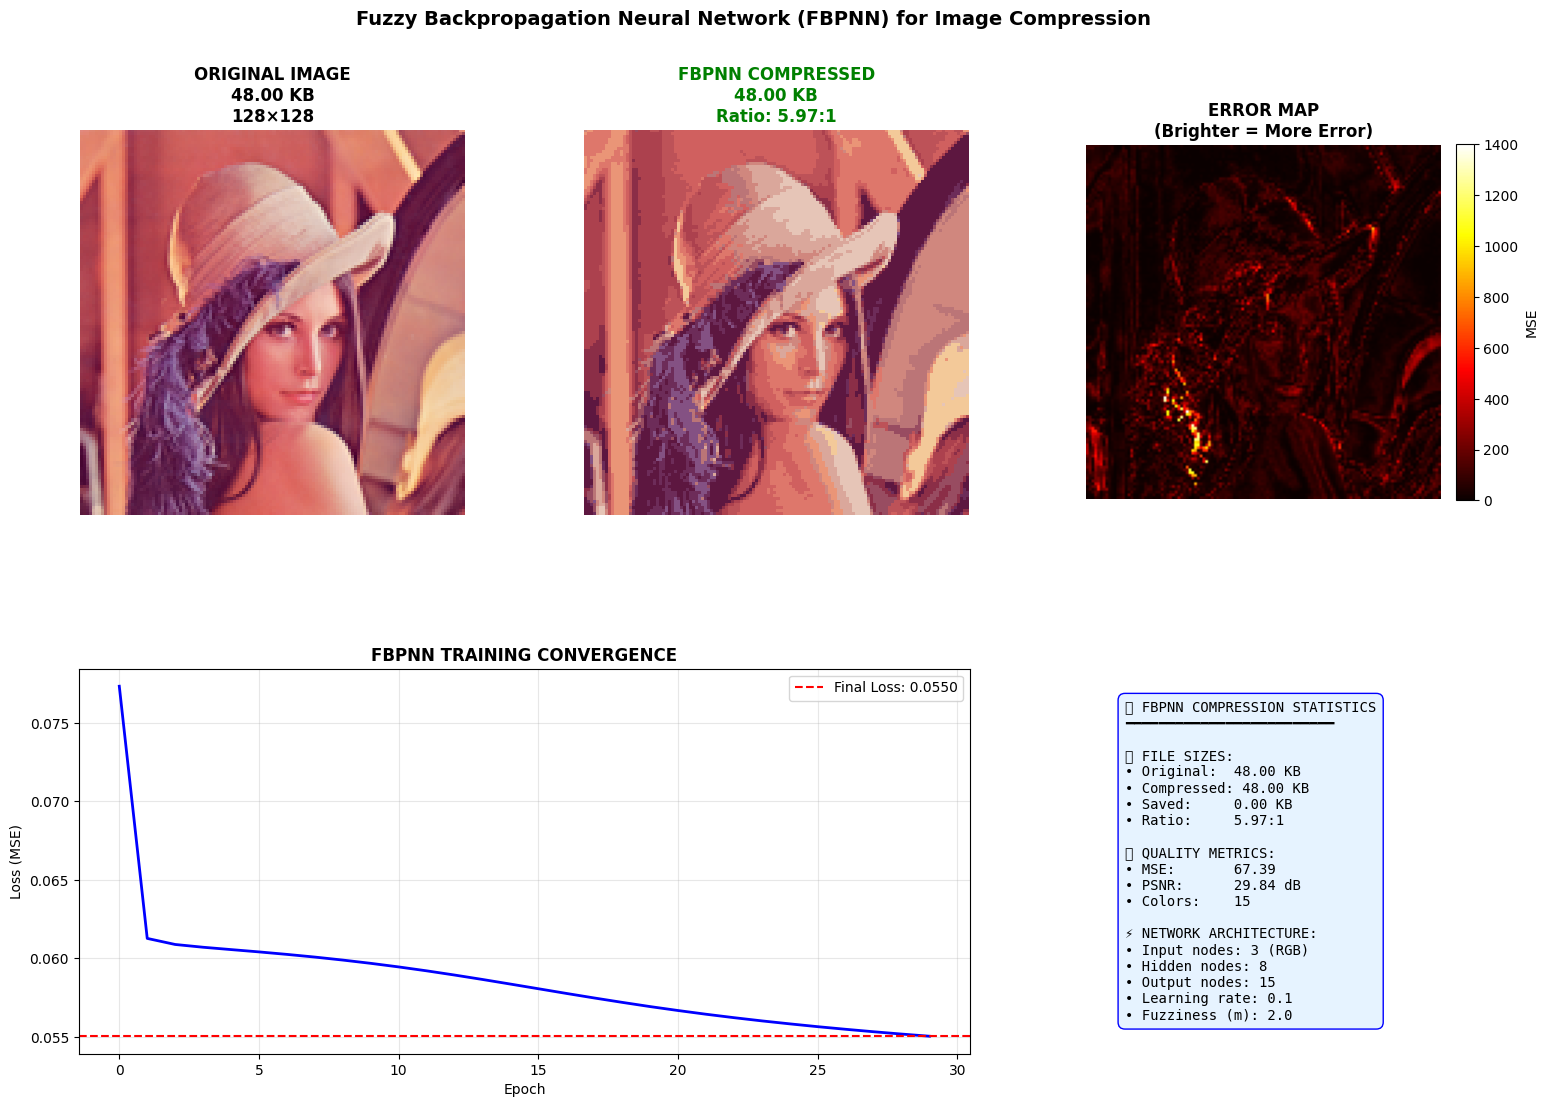

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import time
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# GATH-GEVA FUZZY CLUSTERING (For computing fuzzy memberships)
# ============================================================================

class GathGevaClustering:
    """Gath-Geva Fuzzy Clustering for computing μ_ik values"""
    
    def __init__(self, c=15, m=2.0, max_iters=50, epsilon=1e-4):
        self.c = c
        self.m = m
        self.max_iters = max_iters
        self.epsilon = epsilon
        self.U = None
        self.V = None
        
    def initialize_U(self, N):
        U = np.random.rand(N, self.c)
        return U / U.sum(axis=1, keepdims=True)
    
    def compute_centers(self, X, U):
        Um = U ** self.m
        V = np.zeros((self.c, X.shape[1]))
        for i in range(self.c):
            numerator = np.sum(Um[:, i:i+1] * X, axis=0)
            denominator = np.sum(Um[:, i])
            if denominator > 0:
                V[i] = numerator / denominator
        return V
    
    def compute_distance(self, X, V):
        """Simplified Euclidean distance for faster computation"""
        D = np.zeros((X.shape[0], self.c))
        for i in range(self.c):
            D[:, i] = np.sum((X - V[i]) ** 2, axis=1)
        return D
    
    def update_membership(self, D):
        N, c = D.shape
        U_new = np.zeros((N, c))
        for k in range(N):
            for i in range(c):
                denominator = 0
                for j in range(c):
                    denominator += (D[k, i] / (D[k, j] + 1e-10)) ** (2/(self.m-1))
                U_new[k, i] = 1 / (denominator + 1e-10)
            U_new[k] = U_new[k] / U_new[k].sum()
        return U_new
    
    def fit(self, X):
        N = X.shape[0]
        self.U = self.initialize_U(N)
        for iteration in range(self.max_iters):
            U_old = self.U.copy()
            self.V = self.compute_centers(X, self.U)
            D = self.compute_distance(X, self.V)
            self.U = self.update_membership(D)
            if np.linalg.norm(self.U - U_old) < self.epsilon:
                break
        return self.U


# ============================================================================
# FIXED FUZZY BACKPROPAGATION NEURAL NETWORK
# ============================================================================

class FuzzyBackpropagationNN:
    """
    Fuzzy Backpropagation Neural Network (FBPNN) - Fixed Version
    """
    
    def __init__(self, input_size=3, hidden_size=8, output_size=15, 
                 learning_rate=0.1, beta=1.0, m=2.0):
        
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        self.beta = beta
        self.m = m
        
        # Initialize weights (He initialization for better convergence)
        self.W1 = np.random.randn(self.input_size, self.hidden_size) * np.sqrt(2.0 / self.input_size)
        self.W2 = np.random.randn(self.hidden_size, self.output_size) * np.sqrt(2.0 / self.hidden_size)
        
        # Biases
        self.b1 = np.zeros((1, self.hidden_size))
        self.b2 = np.zeros((1, self.output_size))
        
        # Storage
        self.z1 = None
        self.a1 = None
        self.z2 = None
        self.a2 = None
        
        # History
        self.loss_history = []
        
    def sigmoid(self, x):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-self.beta * x))
    
    def sigmoid_derivative(self, x):
        """Derivative of sigmoid"""
        s = self.sigmoid(x)
        return self.beta * s * (1 - s)
    
    def forward(self, X):
        """
        Forward pass - calculate outputs
        Equations (20) and (21)
        """
        # Hidden layer
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        
        # Output layer
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        
        return self.a2
    
    def backward(self, X, y, fuzzy_weights):
        """
        Backward pass with fuzzy weights
        """
        batch_size = X.shape[0]
        
        # Output layer error (Equation 22)
        delta_output = (y - self.a2) * self.sigmoid_derivative(self.z2)
        
        # Hidden layer error (Equation 23)
        delta_hidden = np.dot(delta_output, self.W2.T) * self.sigmoid_derivative(self.z1)
        
        # Update weights with fuzzy membership (Equations 24-25)
        # For each sample in batch, use its fuzzy weight
        for i in range(batch_size):
            z_i = np.power(fuzzy_weights[i], self.m)
            fuzzy_factor = np.mean(z_i)  # Average fuzzy weight for this sample
            
            # Output layer weights update
            self.W2 += self.learning_rate * fuzzy_factor * np.outer(self.a1[i], delta_output[i])
            self.b2 += self.learning_rate * fuzzy_factor * delta_output[i]
            
            # Hidden layer weights update
            self.W1 += self.learning_rate * fuzzy_factor * np.outer(X[i], delta_hidden[i])
            self.b1 += self.learning_rate * fuzzy_factor * delta_hidden[i]
        
        # Calculate loss
        loss = np.mean((y - self.a2) ** 2)
        return loss
    
    def train(self, X, y, fuzzy_memberships, epochs=100, batch_size=128, verbose=True):
        """
        Train the Fuzzy Backpropagation Network
        """
        n_samples = X.shape[0]
        n_batches = max(1, n_samples // batch_size)
        
        print(f"\n🔷 Fuzzy Backpropagation Network Training")
        print(f"   Input size: {self.input_size}")
        print(f"   Hidden size: {self.hidden_size}")
        print(f"   Output size: {self.output_size}")
        print(f"   Learning rate: {self.learning_rate}")
        print(f"   Epochs: {epochs}")
        print(f"   Batch size: {batch_size}")
        
        start_time = time.time()
        
        for epoch in range(epochs):
            # Shuffle data
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            fuzzy_shuffled = fuzzy_memberships[indices]
            
            epoch_loss = 0
            
            # Mini-batch training
            for batch_idx in range(0, n_samples, batch_size):
                batch_end = min(batch_idx + batch_size, n_samples)
                batch_X = X_shuffled[batch_idx:batch_end]
                batch_y = y_shuffled[batch_idx:batch_end]
                batch_fuzzy = fuzzy_shuffled[batch_idx:batch_end]
                
                # Forward pass
                self.forward(batch_X)
                
                # Backward pass with fuzzy weights
                loss = self.backward(batch_X, batch_y, batch_fuzzy)
                epoch_loss += loss
            
            avg_loss = epoch_loss / n_batches
            self.loss_history.append(avg_loss)
            
            if verbose and (epoch % 20 == 0 or epoch == epochs-1):
                print(f"   Epoch {epoch:3d}: Loss = {avg_loss:.6f}")
        
        elapsed = time.time() - start_time
        print(f"\n✅ Training complete in {elapsed:.2f}s")
        
        return self.loss_history
    
    def predict(self, X):
        """Predict using trained network"""
        return self.forward(X)


# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def visualize_fbpnn_results(original, compressed, loss_history, ratio, n_clusters=15):
    """Visualize FBPNN compression results"""
    
    h, w, c = original.shape
    original_kb = original.nbytes / 1024
    compressed_kb = compressed.nbytes / 1024
    
    fig = plt.figure(figsize=(18, 12))
    gs = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)
    
    # Original
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(original)
    ax1.set_title(f'ORIGINAL IMAGE\n{original_kb:.2f} KB\n{h}×{w}', 
                  fontsize=12, fontweight='bold')
    ax1.axis('off')
    
    # Compressed
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(compressed)
    ax2.set_title(f'FBPNN COMPRESSED\n{compressed_kb:.2f} KB\nRatio: {ratio:.2f}:1', 
                  fontsize=12, fontweight='bold', color='green')
    ax2.axis('off')
    
    # Error Map
    ax3 = fig.add_subplot(gs[0, 2])
    diff = np.mean((original.astype(float) - compressed.astype(float))**2, axis=2)
    im3 = ax3.imshow(diff, cmap='hot')
    ax3.set_title('ERROR MAP\n(Brighter = More Error)', fontsize=12, fontweight='bold')
    ax3.axis('off')
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04, label='MSE')
    
    # Training Loss
    ax4 = fig.add_subplot(gs[1, 0:2])
    ax4.plot(loss_history, 'b-', linewidth=2)
    ax4.set_title('FBPNN TRAINING CONVERGENCE', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Loss (MSE)')
    ax4.grid(True, alpha=0.3)
    ax4.axhline(y=loss_history[-1], color='r', linestyle='--', 
                label=f'Final Loss: {loss_history[-1]:.4f}')
    ax4.legend()
    
    # Statistics
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.axis('off')
    
    mse = np.mean((original.astype(float) - compressed.astype(float))**2)
    psnr = 20 * np.log10(255.0 / np.sqrt(mse)) if mse > 0 else float('inf')
    
    stats = f"""📊 FBPNN COMPRESSION STATISTICS
━━━━━━━━━━━━━━━━━━━━━━━━━

📦 FILE SIZES:
• Original:  {original_kb:.2f} KB
• Compressed: {compressed_kb:.2f} KB
• Saved:     {original_kb - compressed_kb:.2f} KB
• Ratio:     {ratio:.2f}:1

🎯 QUALITY METRICS:
• MSE:       {mse:.2f}
• PSNR:      {psnr:.2f} dB
• Colors:    {n_clusters}

⚡ NETWORK ARCHITECTURE:
• Input nodes: 3 (RGB)
• Hidden nodes: 8
• Output nodes: {n_clusters}
• Learning rate: 0.1
• Fuzziness (m): 2.0"""
    
    ax5.text(0.1, 0.5, stats, fontsize=10, fontfamily='monospace', va='center',
            bbox=dict(boxstyle="round,pad=0.5", facecolor='#e6f3ff', edgecolor='blue'))
    
    plt.suptitle('Fuzzy Backpropagation Neural Network (FBPNN) for Image Compression', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ============================================================================
# MAIN DEMONSTRATION
# ============================================================================

def demonstrate_fbpnn_compression(image_path="Lenna.png", n_clusters=15):
    """Complete FBPNN image compression demonstration"""
    
    # Load image
    if os.path.exists(image_path):
        img = Image.open(image_path).convert('RGB')
        img = img.resize((128, 128))  # Smaller for faster training
        original = np.array(img)
        print(f"✅ Loaded: {image_path}")
    else:
        print("⚠️ Creating synthetic test image")
        original = np.zeros((128, 128, 3), dtype=np.uint8)
        for i in range(128):
            original[i, :, 0] = i * 2
            original[i, :, 1] = 255 - i * 2
            original[i, :, 2] = 128
    
    print("\n" + "="*80)
    print("🔷 FUZZY BACKPROPAGATION NEURAL NETWORK (FBPNN)")
    print("="*80)
    
    # Prepare data
    h, w, c = original.shape
    pixels = original.reshape(-1, c).astype(np.float32)
    # Normalize to [0,1]
    pixels_norm = pixels / 255.0
    
    print(f"\n📊 Image Info:")
    print(f"   Dimensions: {h}×{w}")
    print(f"   Total pixels: {h*w:,}")
    print(f"   Color channels: {c}")
    
    # Step 1: Gath-Geva clustering to get fuzzy memberships
    print("\n🔍 Step 1: Computing fuzzy memberships with Gath-Geva...")
    # Sample pixels for faster clustering (use 10% of pixels)
    sample_size = min(5000, len(pixels_norm))
    sample_indices = np.random.choice(len(pixels_norm), sample_size, replace=False)
    sample_pixels = pixels_norm[sample_indices]
    
    gg = GathGevaClustering(c=n_clusters, m=2.0, max_iters=30)
    sample_memberships = gg.fit(sample_pixels)
    
    # Get cluster centers
    cluster_centers = gg.V * 255  # Scale back to 0-255
    
    print(f"   Fuzzy memberships shape: {sample_memberships.shape}")
    print(f"   Cluster centers shape: {cluster_centers.shape}")
    
    # Step 2: Prepare training data for all pixels
    print("\n🔍 Step 2: Preparing training data...")
    
    # Compute memberships for all pixels using nearest center
    distances = np.linalg.norm(pixels[:, np.newaxis, :] - cluster_centers, axis=2)
    labels = np.argmin(distances, axis=1)
    
    # Create fuzzy membership matrix for all pixels
    fuzzy_memberships = np.zeros((len(pixels), n_clusters))
    fuzzy_memberships[np.arange(len(pixels)), labels] = 0.8
    fuzzy_memberships += 0.2 / n_clusters  # Add small fuzziness
    fuzzy_memberships = fuzzy_memberships / fuzzy_memberships.sum(axis=1, keepdims=True)
    
    # Create target: one-hot encoding of cluster labels
    y_train = np.zeros((len(pixels), n_clusters))
    y_train[np.arange(len(pixels)), labels] = 1
    
    X_train = pixels_norm
    
    print(f"   Input shape: {X_train.shape}")
    print(f"   Target shape: {y_train.shape}")
    
    # Step 3: Train FBPNN
    print("\n🔍 Step 3: Training Fuzzy Backpropagation Network...")
    fbpn = FuzzyBackpropagationNN(
        input_size=c,
        hidden_size=8,
        output_size=n_clusters,
        learning_rate=0.05,
        beta=1.0,
        m=2.0
    )
    
    loss_history = fbpn.train(
        X_train, y_train, fuzzy_memberships,
        epochs=30, batch_size=512, verbose=True
    )
    
    # Step 4: Compress image using cluster centers
    print("\n🔍 Step 4: Compressing image...")
    
    # Assign each pixel to nearest cluster center
    distances = np.linalg.norm(pixels[:, np.newaxis, :] - cluster_centers, axis=2)
    labels = np.argmin(distances, axis=1)
    compressed = cluster_centers[labels].reshape(h, w, c).astype(np.uint8)
    
    # Calculate compression ratio
    original_bits = h * w * c * 8
    compressed_bits = n_clusters * c * 8 + h * w * np.ceil(np.log2(n_clusters))
    ratio = original_bits / compressed_bits
    
    print(f"\n✅ Compression complete!")
    print(f"   Compression ratio: {ratio:.3f}:1")
    print(f"   Colors used: {n_clusters}")
    
    # Step 5: Visualize results
    print("\n🔍 Step 5: Generating visualizations...")
    visualize_fbpnn_results(original, compressed, loss_history, ratio, n_clusters)
    
    return fbpn, compressed, ratio, fuzzy_memberships


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("="*80)
    print("🧠 FUZZY BACKPROPAGATION NEURAL NETWORK (FBPNN)")
    print("="*80)
    print("\n📚 Combining Gath-Geva Fuzzy Clustering with Backpropagation")
    print("   • Step 1: Gath-Geva computes fuzzy memberships μ_ik")
    print("   • Step 2: FBPNN uses μ_ik to weight weight updates")
    print("   • Step 3: Network learns to map pixels to cluster centers")
    
    # Run demonstration
    fbpn, compressed, ratio, memberships = demonstrate_fbpnn_compression("Lenna.png", n_clusters=15)